# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [3]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy.stats import linregress

# Impor the OpenWeatherMap API key
from api_keys import weather_api_key

# Install citipy if not already installed
%pip install citipy

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

Note: you may need to restart the kernel to use updated packages.


### Generate the Cities List by Using the `citipy` Library

In [4]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name

    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 554


---

## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [5]:
# Set the API base URL
url = "https://api.openweathermap.org/data/2.5/weather?"

# Define an empty list to fetch the weather data for each city
city_data = []

# Print to logger
print("Beginning Data Retrieval     ")
print("-----------------------------")

# Create counters
record_count = 1
set_count = 1

# Loop through all the cities in our list to fetch weather data
for i, city in enumerate(cities):

    # Group cities in sets of 50 for logging purposes
    if (i % 50 == 0 and i >= 50):
        set_count += 1
        record_count = 0

    # Create endpoint URL with each city
    city_url = f"{url}appid={weather_api_key}&q={city}&units=metric"

    # Log the url, record, and set numbers
    print("Processing Record %s of Set %s | %s" % (record_count, set_count, city))

    # Add 1 to the record count
    record_count += 1

    # Run an API request for each of the cities
    try:
        # Parse the JSON and retrieve data
        city_weather = requests.get(city_url).json()

        # Parse out latitude, longitude, max temp, humidity, cloudiness, wind speed, country, and date
        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]["lon"]
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds = city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = city_weather["dt"]

        # Append the City information into city_data list
        city_data.append({"City": city,
                          "Lat": city_lat,
                          "Lng": city_lng,
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})

    # If an error is experienced, skip the city
    except:
        print("City not found. Skipping...")
        pass

    # pause to avoid rate limiting
    time.sleep(1)

# Indicate that Data Loading is complete
print("-----------------------------")
print("Data Retrieval Complete      ")
print("-----------------------------")

Beginning Data Retrieval     
-----------------------------
Processing Record 1 of Set 1 | alakurtti
Processing Record 2 of Set 1 | college
Processing Record 3 of Set 1 | nemuro
Processing Record 4 of Set 1 | port elizabeth
Processing Record 5 of Set 1 | grytviken
Processing Record 6 of Set 1 | whitehorse
Processing Record 7 of Set 1 | albany
Processing Record 8 of Set 1 | thompson
Processing Record 9 of Set 1 | lebu
Processing Record 10 of Set 1 | taiohae
City not found. Skipping...
Processing Record 11 of Set 1 | adamstown
Processing Record 12 of Set 1 | hithadhoo
Processing Record 13 of Set 1 | anacapri
Processing Record 14 of Set 1 | margaret river
Processing Record 15 of Set 1 | port-aux-francais
Processing Record 16 of Set 1 | west island
Processing Record 17 of Set 1 | sola
Processing Record 18 of Set 1 | sao miguel do araguaia
Processing Record 19 of Set 1 | isafjordur
Processing Record 20 of Set 1 | bethel
Processing Record 21 of Set 1 | iqaluit
Processing Record 22 of Set 1 |

In [6]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)

# Show Record Count
city_data_df.count()

City          540
Lat           540
Lng           540
Max Temp      540
Humidity      540
Cloudiness    540
Wind Speed    540
Country       540
Date          540
dtype: int64

In [7]:
# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,alakurtti,66.9672,30.3491,-0.01,89,29,3.17,RU,1743627027
1,college,64.8569,-147.8028,1.76,87,100,3.60,US,1743627028
2,nemuro,43.3236,145.5750,0.28,95,100,12.15,JP,1743627030
3,port elizabeth,-33.9180,25.5701,15.73,94,0,2.06,ZA,1743627031
4,grytviken,-54.2811,-36.5092,5.28,98,100,9.66,GS,1743627032


In [8]:
# Export the City_Data into a csv
city_data_df.to_csv("output_data/cities.csv", index_label="City_ID")

In [9]:
# Read saved data
city_data_df = pd.read_csv("output_data/cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,alakurtti,66.9672,30.3491,-0.01,89,29,3.17,RU,1743627027
1,college,64.8569,-147.8028,1.76,87,100,3.60,US,1743627028
2,nemuro,43.3236,145.5750,0.28,95,100,12.15,JP,1743627030
3,port elizabeth,-33.9180,25.5701,15.73,94,0,2.06,ZA,1743627031
4,grytviken,-54.2811,-36.5092,5.28,98,100,9.66,GS,1743627032


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

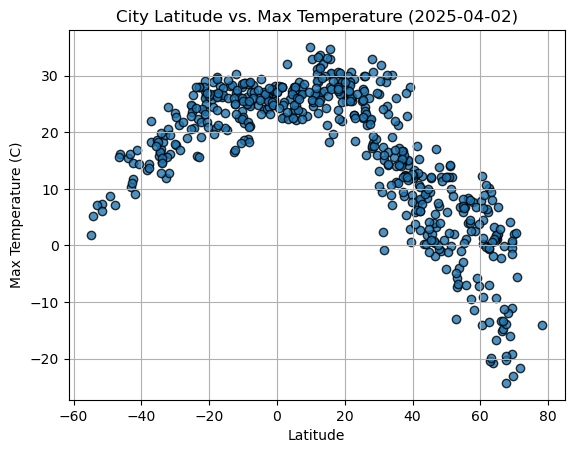

In [10]:
# Build scatter plot for latitude vs. temperature
plt.scatter(city_data_df["Lat"], city_data_df["Max Temp"], edgecolor="black", linewidths=1, marker="o", alpha=0.8, label="Cities")

# Incorporate the other graph properties
plt.title("City Latitude vs. Max Temperature (%s)" % time.strftime("%x"))
plt.ylabel("Max Temperature (C)")
plt.xlabel("Latitude")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig1.png")

# Show plot
plt.show()

#### Latitude Vs. Humidity

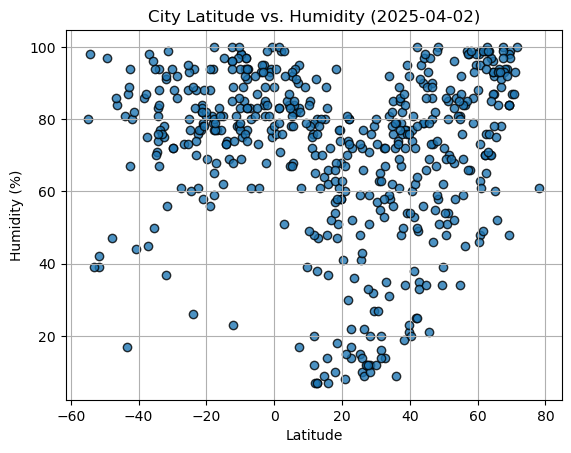

In [11]:
# Build the scatter plots for latitude vs. humidity
plt.scatter(city_data_df["Lat"], city_data_df["Humidity"], edgecolor="black", linewidths=1, marker="o", alpha=0.8, label="Cities")

# Incorporate the other graph properties
plt.title("City Latitude vs. Humidity (%s)" % time.strftime("%x"))
plt.ylabel("Humidity (%)")
plt.xlabel("Latitude")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig2.png")

# Show plot
plt.show()

#### Latitude Vs. Cloudiness

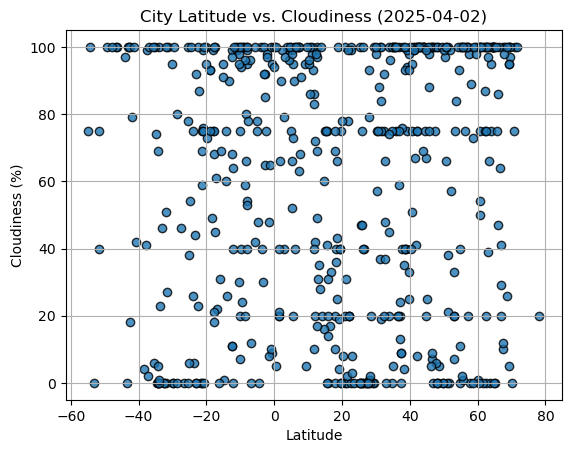

In [12]:
# Build the scatter plots for latitude vs. cloudiness
plt.scatter(city_data_df["Lat"], city_data_df["Cloudiness"], edgecolor="black", linewidths=1, marker="o", alpha=0.8, label="Cities")

# Incorporate the other graph properties
plt.title("City Latitude vs. Cloudiness (%s)" % time.strftime("%x"))
plt.ylabel("Cloudiness (%)")
plt.xlabel("Latitude")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig3.png")

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

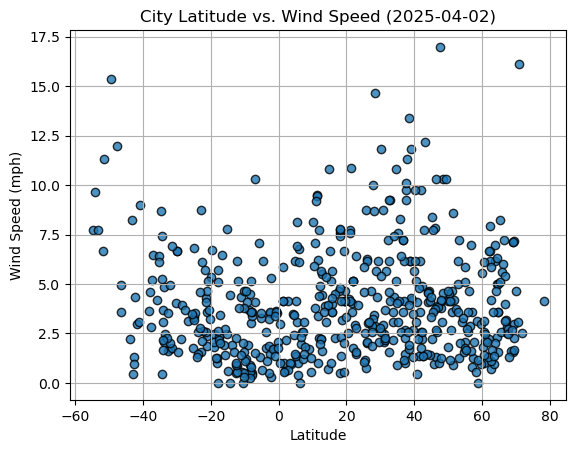

In [13]:
# Build the scatter plots for latitude vs. wind speed
plt.scatter(city_data_df["Lat"], city_data_df["Wind Speed"], edgecolor="black", linewidths=1, marker="o", alpha=0.8, label="Cities")

# Incorporate the other graph properties
plt.title("City Latitude vs. Wind Speed (%s)" % time.strftime("%x"))
plt.ylabel("Wind Speed (mph)")
plt.xlabel("Latitude")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig4.png")

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [14]:
# Define a function to create Linear Regression plots
def linear_regression(x_values, y_values):
    (slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
    regress_values = x_values * slope + intercept
    line_eq = "y = " + str(round(slope, 2)) + "x + " + str(round(intercept, 2))

    return slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq

In [15]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
northern_hemi_df = city_data_df.loc[(city_data_df["Lat"] >= 0)]

# Display sample data
northern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,alakurtti,66.9672,30.3491,-0.01,89,29,3.17,RU,1743627027
1,college,64.8569,-147.8028,1.76,87,100,3.60,US,1743627028
2,nemuro,43.3236,145.5750,0.28,95,100,12.15,JP,1743627030
5,whitehorse,60.7161,-135.0538,4.43,48,75,1.03,CA,1743627033
6,albany,42.6001,-73.9662,7.97,35,100,1.34,US,1743627004


In [16]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
southern_hemi_df = city_data_df.loc[(city_data_df["Lat"] < 0)] 

# Display sample data
southern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
3,port elizabeth,-33.9180,25.5701,15.73,94,0,2.06,ZA,1743627031
4,grytviken,-54.2811,-36.5092,5.28,98,100,9.66,GS,1743627032
8,lebu,-37.6167,-73.6500,14.35,75,99,2.85,CL,1743627037
9,adamstown,-25.0660,-130.1015,24.64,80,38,6.83,PN,1743627039
10,hithadhoo,-0.6000,73.0833,28.15,75,9,3.55,MV,1743627040


###  Temperature vs. Latitude Linear Regression Plot

The r-value is: 0.7511578160950885


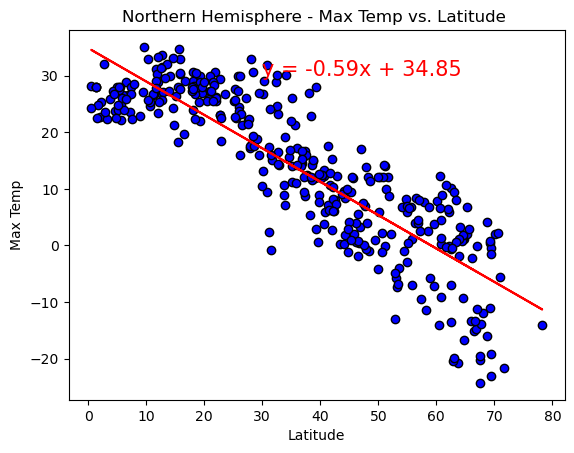

In [17]:
# Linear regression on Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Max Temp"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Max Temp")
plt.title("Northern Hemisphere - Max Temp vs. Latitude ")
plt.show()



The r-value is: 0.6177628830659968


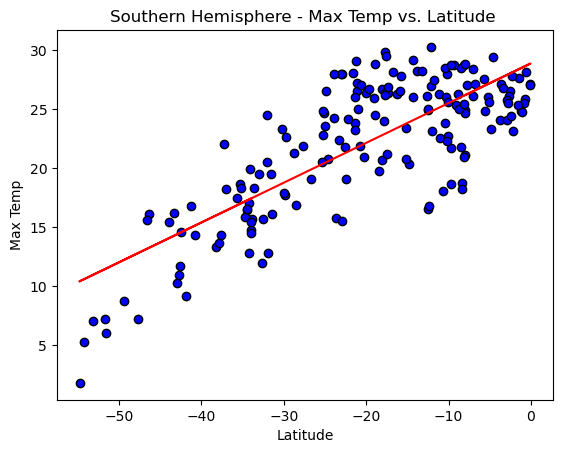

In [18]:
# Linear regression on Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Max Temp"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Max Temp")
plt.title("Southern Hemisphere - Max Temp vs. Latitude ")
plt.show()

**Discussion about the linear relationship:** 
The two images show linear regression models applied to the relationship between latitude and maximum temperature for the Northern and Southern Hemispheres.

**Northern Hemisphere**
- The regression equation is **\( y = -0.59x + 34.85 \)**.
- The negative slope (-0.59) indicates that as latitude increases, the maximum temperature decreases. This aligns with expectations, as regions closer to the poles tend to be colder.
- The data points are closely aligned with the regression line, suggesting a strong correlation.

**Southern Hemisphere (Second Image)**
- The regression line has a positive slope, meaning as latitude increases (moving toward the equator), the maximum temperature also increases.
- The r-value is **0.6177**, indicating a moderate positive correlation.
- The spread of data points suggests some variability, but the trend remains clear.

**Comparison**
- Both hemispheres show a strong correlation between latitude and maximum temperature.
- The negative slope in the Northern Hemisphere and the positive slope in the Southern Hemisphere reflect the expected pattern: temperatures decrease as one moves away from the equator in both directions.
- The absolute value of the slope appears larger in the Northern Hemisphere, possibly due to differences in landmass distribution and climate variability.

### Humidity vs. Latitude Linear Regression Plot

The r-value is: 0.0746212455377093


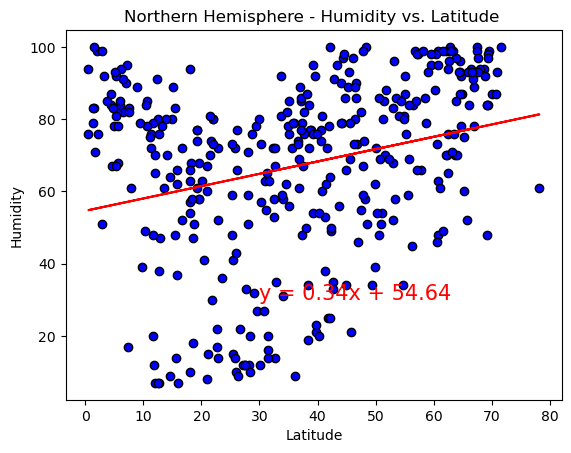

In [19]:
# Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Humidity"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Humidity")
plt.title("Northern Hemisphere - Humidity vs. Latitude ")
plt.show()

The r-value is: 0.08103689544301348


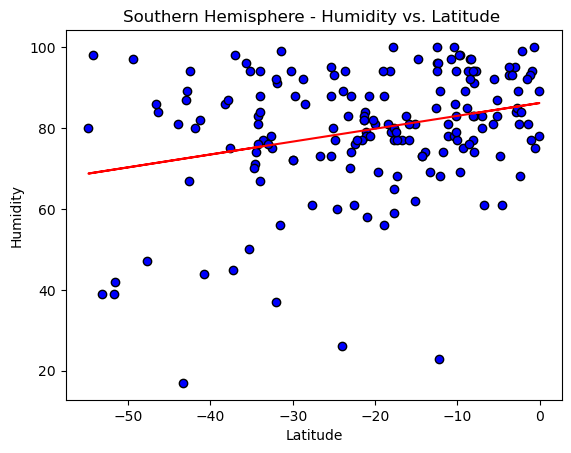

In [20]:
# Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Humidity"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Humidity")
plt.title("Southern Hemisphere - Humidity vs. Latitude ")
plt.show()

**Discussion about the linear relationship:** 

In the Northern Hemisphere scatter plot, the trend line reveals how humidity changes with latitude. If the line has a positive slope, it suggests humidity tends to rise as latitude increases; if negative, it implies the opposite. The scatter of points around the line indicates the strength of this correlation—closer clustering means stronger correlation.

Similarly, the Southern Hemisphere plot shows latitude moving in the negative direction. The trend line here tells us if there's a positive, negative, or negligible relationship between humidity and latitude for these latitudes. Comparing both trend lines highlights differences in correlation strength or direction between the hemispheres, providing insight into their climatic characteristics

### Cloudiness vs. Latitude Linear Regression Plot

The r-value is: 0.00888299818874084


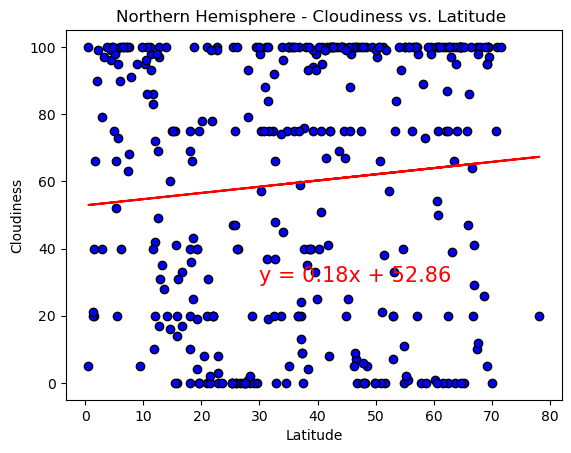

In [21]:
# Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Cloudiness"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness")
plt.title("Northern Hemisphere - Cloudiness vs. Latitude ")
plt.show()

The r-value is: 0.011370558754267904


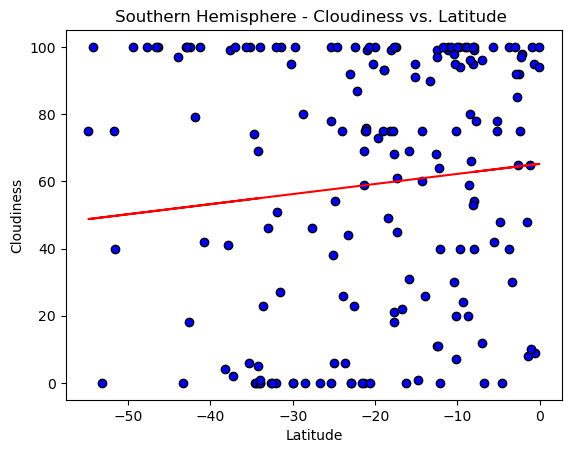

In [22]:
# Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Cloudiness"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness")
plt.title("Southern Hemisphere - Cloudiness vs. Latitude ")
plt.show()

**Discussion about the linear relationship:** 
In both the Northern and Southern Hemispheres, the linear regression between cloudiness and latitude shows a very weak positive slope. The r-values are close to zero (0.0088 and 0.0114), indicating no significant linear relationship. The data points are widely scattered, suggesting that cloudiness is not strongly influenced by latitude, and is likely affected more by local weather conditions.

### Wind Speed vs. Latitude Linear Regression Plot

The r-value is: 4.93140358075401e-05


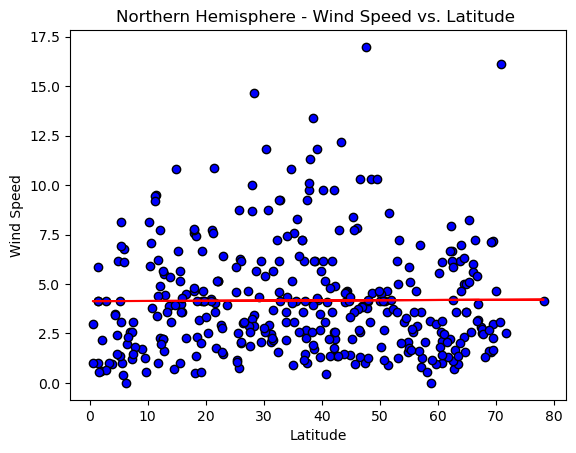

In [23]:
# Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Wind Speed"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed")
plt.title("Northern Hemisphere - Wind Speed vs. Latitude ")
plt.show()

The r-value is: 0.18828324089783213


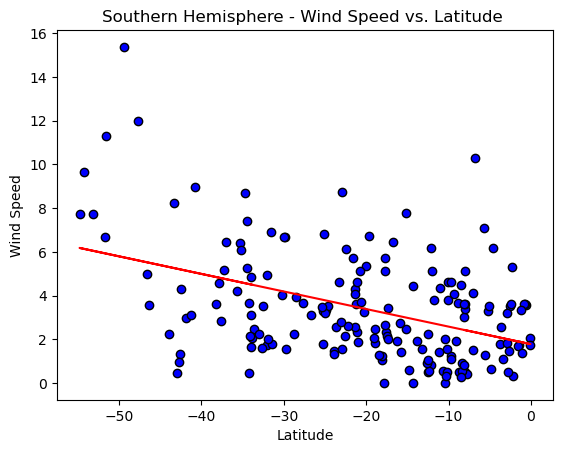

In [24]:
# Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Wind Speed"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed")
plt.title("Southern Hemisphere - Wind Speed vs. Latitude ")
plt.show()

**Discussion about the linear relationship:** 
For the Northern Hemisphere, the scatter plot shows a nearly flat trend line with an r-value of approximately 0.005, indicating no significant linear correlation between latitude and wind speed. This means that changes in latitude do not appear to influence wind speed in this region.

For the Southern Hemisphere, the trend line slopes downward slightly, with an r-value of about -0.188, reflecting a weak negative correlation. This suggests that as latitude becomes more negative (closer to the South Pole), wind speed shows a slight tendency to decrease. 

In summary, the Northern Hemisphere shows no meaningful relationship, while the Southern Hemisphere exhibits a weak negative correlation between wind speed and latitude. 